# 06b — Evaluation: Onset Forecast (3-month-ahead)

Evaluation of the onset predictions from notebook 05b.

**Setup recap:**
- **Target:** `onset = 1` if not currently in shock and a Sahm shock begins within the next h=3 months; `NaN` when already in shock
- **OOS window:** 36 months (2022-01 → 2024-12), `n_splits=36`, `gap=2`
- **Model:** Random Forest (`class_weight='balanced'`)
- **Evaluation pool:** only rows where onset is not NaN (states not currently in shock)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from sklearn.metrics import (
    roc_curve, roc_auc_score,
    precision_recall_curve, average_precision_score,
    f1_score, matthews_corrcoef, brier_score_loss,
    balanced_accuracy_score, confusion_matrix, log_loss,
    accuracy_score,
)

P   = Path("../data/processed")
FIG = Path("../output/figures")
TBL = Path("../output/tables")
FIG.mkdir(parents=True, exist_ok=True)
TBL.mkdir(parents=True, exist_ok=True)

MODELS     = ["M0", "M2", "M3", "M4"]
MODEL_COLS = {"M0": "#888888", "M2": "#2171b5", "M3": "#41ab5d", "M4": "#d7301f"}
MODEL_DASH = {"M0": (4,2), "M2": (6,2), "M3": (3,2), "M4": "solid"}

raw = pd.read_parquet(P / "onset_predictions.parquet")
raw = raw.reset_index()   # flatten MultiIndex → state_code, date columns
raw["year"] = raw["date"].dt.year

TARGET = "ons_anysahm_shock_th0_h3"

# Evaluation pool: drop NaN onset rows (states currently in shock)
preds = raw.dropna(subset=[TARGET]).copy()
preds[TARGET] = preds[TARGET].astype(int)

base_rate = preds[TARGET].mean()
n_pos     = int(preds[TARGET].sum())
n_total   = len(preds)

print(f"Loaded {len(raw):,} raw rows  |  NaN onset (in-shock) rows dropped: {len(raw)-len(preds)}")
print(f"Evaluation pool: {n_total:,} rows  |  positives: {n_pos}  ({base_rate:.2%} base rate)")
print(f"Date range: {preds['date'].min().strftime('%Y-%m')} → {preds['date'].max().strftime('%Y-%m')}")

Loaded 1,836 raw rows  |  NaN onset (in-shock) rows dropped: 389
Evaluation pool: 1,447 rows  |  positives: 104  (7.19% base rate)
Date range: 2022-01 → 2024-09


## 1 — Pooled ROC curves

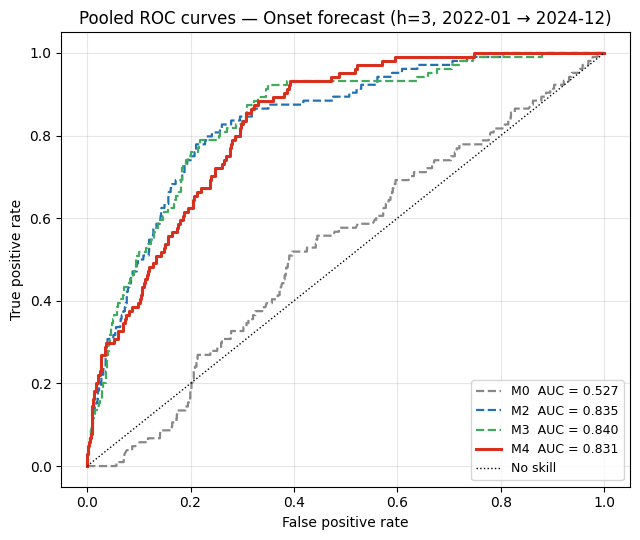

Saved → output/figures/06b_roc_pooled.png


In [2]:
fig, ax = plt.subplots(figsize=(6.5, 5.5))

for m in MODELS:
    col = f"ons_preds_{m}"
    fpr, tpr, _ = roc_curve(preds[TARGET], preds[col])
    auc = roc_auc_score(preds[TARGET], preds[col])
    ls  = MODEL_DASH[m] if isinstance(MODEL_DASH[m], str) else "--"
    lw  = 2.2 if m == "M4" else 1.6
    ax.plot(fpr, tpr, color=MODEL_COLS[m], lw=lw,
            linestyle=ls, label=f"{m}  AUC = {auc:.3f}")

ax.plot([0, 1], [0, 1], "k:", lw=1, label="No skill")
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.set_title("Pooled ROC curves — Onset forecast (h=3, 2022-01 → 2024-12)")
ax.legend(loc="lower right", fontsize=9)
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(FIG / "06b_roc_pooled.png", dpi=150)
plt.show()
print("Saved → output/figures/06b_roc_pooled.png")

## 2 — Pooled PR curves

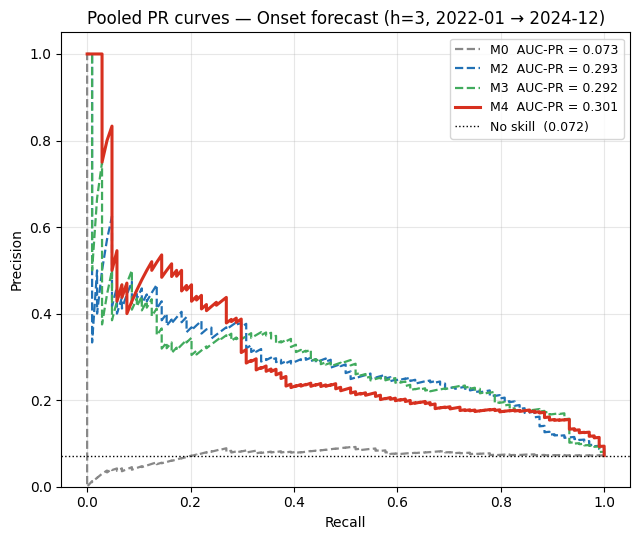

Saved → output/figures/06b_pr_pooled.png


In [3]:
fig, ax = plt.subplots(figsize=(6.5, 5.5))

for m in MODELS:
    col = f"ons_preds_{m}"
    prec, rec, _ = precision_recall_curve(preds[TARGET], preds[col])
    ap  = average_precision_score(preds[TARGET], preds[col])
    ls  = MODEL_DASH[m] if isinstance(MODEL_DASH[m], str) else "--"
    lw  = 2.2 if m == "M4" else 1.6
    ax.plot(rec, prec, color=MODEL_COLS[m], lw=lw,
            linestyle=ls, label=f"{m}  AUC-PR = {ap:.3f}")

ax.axhline(base_rate, color="k", lw=1, linestyle=":",
           label=f"No skill  ({base_rate:.3f})")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Pooled PR curves — Onset forecast (h=3, 2022-01 → 2024-12)")
ax.legend(loc="upper right", fontsize=9)
ax.grid(alpha=0.3)
ax.set_ylim(bottom=0)
fig.tight_layout()
fig.savefig(FIG / "06b_pr_pooled.png", dpi=150)
plt.show()
print("Saved → output/figures/06b_pr_pooled.png")

## 3 — Headline metrics table

In [4]:
rows = []
for m in MODELS:
    col = f"ons_preds_{m}"
    rows.append({
        "model":     m,
        "AUC_ROC":   round(roc_auc_score(preds[TARGET], preds[col]), 4),
        "AUC_PR":    round(average_precision_score(preds[TARGET], preds[col]), 4),
        "base_rate": round(base_rate, 4),
        "n_onset":   n_pos,
        "n_obs":     n_total,
    })

headline = pd.DataFrame(rows)
headline.to_csv(TBL / "06b_headline_metrics.csv", index=False)
print(headline.to_string(index=False))
print("\nSaved → output/tables/06b_headline_metrics.csv")

model  AUC_ROC  AUC_PR  base_rate  n_onset  n_obs
   M0   0.5274  0.0733     0.0719      104   1447
   M2   0.8354  0.2930     0.0719      104   1447
   M3   0.8397  0.2923     0.0719      104   1447
   M4   0.8305  0.3007     0.0719      104   1447

Saved → output/tables/06b_headline_metrics.csv


## 4 — Time-varying performance (sub-period analysis)

OOS window is only 2022–2024 (36 months), so sub-periods are: 2022, 2023, 2024.

In [5]:
PERIODS = {
    "2022": preds["year"] == 2022,
    "2023": preds["year"] == 2023,
    "2024": preds["year"] == 2024,
}

sp_rows = []
for period, mask in PERIODS.items():
    for m in MODELS:
        col = f"ons_preds_{m}"
        sub = preds[mask]
        n_shocks = int(sub[TARGET].sum())
        if n_shocks < 2 or (sub[TARGET] == 0).all():
            auc_roc = np.nan
            auc_pr  = np.nan
        else:
            auc_roc = round(roc_auc_score(sub[TARGET], sub[col]), 4)
            auc_pr  = round(average_precision_score(sub[TARGET], sub[col]), 4)
        sp_rows.append({
            "period":    period,
            "model":     m,
            "AUC_ROC":   auc_roc,
            "AUC_PR":    auc_pr,
            "n_onset":   n_shocks,
            "n_obs":     len(sub),
            "base_rate": round(sub[TARGET].mean(), 4),
        })

sp_df = pd.DataFrame(sp_rows)
sp_df.to_csv(TBL / "06b_subperiod_metrics.csv", index=False)
print(sp_df.to_string(index=False))
print("\nSaved → output/tables/06b_subperiod_metrics.csv")

period model  AUC_ROC  AUC_PR  n_onset  n_obs  base_rate
  2022    M0   0.4143  0.0184       13    610     0.0213
  2022    M2   0.7785  0.0830       13    610     0.0213
  2022    M3   0.7658  0.1132       13    610     0.0213
  2022    M4   0.8790  0.1255       13    610     0.0213
  2023    M0   0.4533  0.0635       40    543     0.0737
  2023    M2   0.8229  0.2535       40    543     0.0737
  2023    M3   0.8167  0.1994       40    543     0.0737
  2023    M4   0.7424  0.1933       40    543     0.0737
  2024    M0   0.6008  0.2207       51    294     0.1735
  2024    M2   0.7725  0.3926       51    294     0.1735
  2024    M3   0.7795  0.4149       51    294     0.1735
  2024    M4   0.7477  0.4113       51    294     0.1735

Saved → output/tables/06b_subperiod_metrics.csv


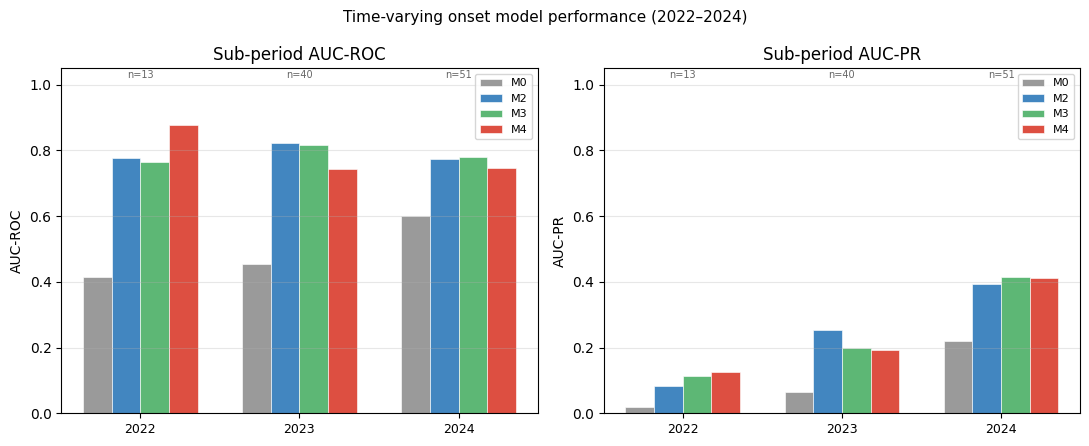

Saved → output/figures/06b_subperiod_performance.png


In [6]:
period_order = list(PERIODS.keys())
x      = np.arange(len(period_order))
width  = 0.18
offsets = np.linspace(-1.5*width, 1.5*width, 4)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharey=False)

for ax, metric, ylabel in [
    (axes[0], "AUC_ROC", "AUC-ROC"),
    (axes[1], "AUC_PR",  "AUC-PR"),
]:
    for i, m in enumerate(MODELS):
        vals = [
            sp_df.loc[(sp_df["period"] == p) & (sp_df["model"] == m), metric].values[0]
            for p in period_order
        ]
        ax.bar(x + offsets[i], vals, width, label=m,
               color=MODEL_COLS[m], alpha=0.85, edgecolor="white", linewidth=0.5)

    ax.set_xticks(x)
    ax.set_xticklabels(period_order, fontsize=9)
    ax.set_ylabel(ylabel)
    ax.set_title(f"Sub-period {ylabel}")
    ax.legend(fontsize=8)
    ax.grid(axis="y", alpha=0.3)
    ax.set_ylim(0, 1.05)
    for pi, period in enumerate(period_order):
        n = sp_df.loc[(sp_df["period"] == period) & (sp_df["model"] == "M4"), "n_onset"].values[0]
        ax.text(x[pi], 1.02, f"n={n}", ha="center", fontsize=7, color="0.4")

fig.suptitle("Time-varying onset model performance (2022–2024)", fontsize=11)
fig.tight_layout()
fig.savefig(FIG / "06b_subperiod_performance.png", dpi=150)
plt.show()
print("Saved → output/figures/06b_subperiod_performance.png")

## 5 — Where does text help most? (comovement analysis)

For each onset event, how many other states also had an onset in the same month?  
Low comovement = idiosyncratic state shock.  High comovement = aggregate shock.  
Hypothesis: Google Trends adds more signal for idiosyncratic shocks.

In [7]:
# Fixed threshold: Youden's J on M4
col_m4 = "ons_preds_M4"
fpr4, tpr4, thresh4 = roc_curve(preds[TARGET], preds[col_m4])
j_idx = np.argmax(tpr4 - fpr4)
TAU   = float(thresh4[j_idx])
print(f"Youden threshold τ = {TAU:.4f}")

# Comovement: number of OTHER states with onset=1 in same month
onset_counts_per_month = (
    preds[preds[TARGET] == 1]
    .groupby("date")["state_code"].count()
    .rename("n_onsets_national")
)
onset_rows = preds[preds[TARGET] == 1].copy()
onset_rows = onset_rows.merge(onset_counts_per_month, on="date", how="left")
onset_rows["comovement"] = onset_rows["n_onsets_national"] - 1

print("\nComovement distribution across onset events:")
print(onset_rows["comovement"].value_counts().sort_index())

def label_comovement(v):
    if v == 0:   return "G1: 0\n(solo)"
    if v <= 3:   return "G2: 1-3\n(low)"
    if v <= 15:  return "G3: 4-15\n(medium)"
    return              "G4: 16+\n(aggregate)"

onset_rows["cov_group"] = onset_rows["comovement"].apply(label_comovement)
cats = ["G1: 0\n(solo)", "G2: 1-3\n(low)", "G3: 4-15\n(medium)", "G4: 16+\n(aggregate)"]
onset_rows["cov_group"] = pd.Categorical(onset_rows["cov_group"], categories=cats, ordered=True)
print("\nOnset events per comovement group:")
print(onset_rows.groupby("cov_group", observed=True)["comovement"].agg(["count","min","max"]))

Youden threshold τ = 0.3821

Comovement distribution across onset events:
comovement
0     7
1     6
2     9
3     8
4    25
5     6
7    24
8     9
9    10
Name: count, dtype: int64

Onset events per comovement group:
                    count  min  max
cov_group                          
G1: 0\n(solo)           7    0    0
G2: 1-3\n(low)         23    1    3
G3: 4-15\n(medium)     74    4    9


In [8]:
col_m3 = "ons_preds_M3"

cov_rows = []
for g_label, grp in onset_rows.groupby("cov_group", observed=True):
    n = len(grp)
    rec_m4 = int((grp[col_m4] >= TAU).sum()) / n
    rec_m3 = int((grp[col_m3] >= TAU).sum()) / n
    cov_rows.append({
        "comovement_group": str(g_label).replace("\n", " "),
        "n_onsets":    n,
        "cov_min":     int(grp["comovement"].min()),
        "cov_max":     int(grp["comovement"].max()),
        "recall_M4":   round(rec_m4, 3),
        "recall_M3":   round(rec_m3, 3),
        "M4_minus_M3": round(rec_m4 - rec_m3, 3),
    })

cov_df = pd.DataFrame(cov_rows)
cov_df.to_csv(TBL / "06b_comovement_recall.csv", index=False)
print(cov_df.to_string(index=False))
print(f"\n(Youden threshold τ = {TAU:.4f})")
print("\nSaved → output/tables/06b_comovement_recall.csv")

 comovement_group  n_onsets  cov_min  cov_max  recall_M4  recall_M3  M4_minus_M3
     G1: 0 (solo)         7        0        0      0.571      1.000       -0.429
    G2: 1-3 (low)        23        1        3      0.870      0.826        0.043
G3: 4-15 (medium)        74        4        9      0.919      0.959       -0.041

(Youden threshold τ = 0.3821)

Saved → output/tables/06b_comovement_recall.csv


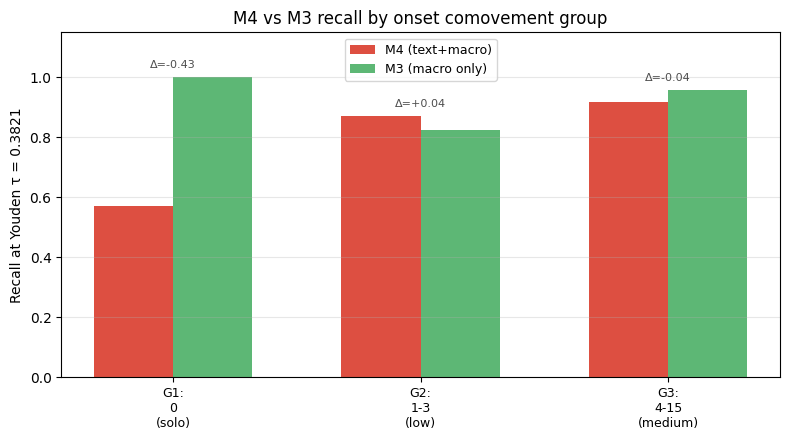

Saved → output/figures/06b_comovement_recall.png


In [9]:
x_cov = np.arange(len(cov_df))
w     = 0.32

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(x_cov - w/2, cov_df["recall_M4"], w,
       label="M4 (text+macro)", color=MODEL_COLS["M4"], alpha=0.85)
ax.bar(x_cov + w/2, cov_df["recall_M3"], w,
       label="M3 (macro only)", color=MODEL_COLS["M3"], alpha=0.85)

for xi, row in cov_df.iterrows():
    delta = row["M4_minus_M3"]
    ymax  = max(row["recall_M4"], row["recall_M3"])
    ax.text(xi, ymax + 0.03, f"Δ={delta:+.2f}", ha="center", fontsize=8, color="0.3")

ax.set_xticks(x_cov)
ax.set_xticklabels(
    [r.replace(" ", "\n") for r in cov_df["comovement_group"]], fontsize=9
)
ax.set_ylabel(f"Recall at Youden τ = {TAU:.4f}")
ax.set_title("M4 vs M3 recall by onset comovement group")
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.3)
ax.set_ylim(0, 1.15)

fig.tight_layout()
fig.savefig(FIG / "06b_comovement_recall.png", dpi=150)
plt.show()
print("Saved → output/figures/06b_comovement_recall.png")

## 6 — Error analysis (M4 at Youden threshold)

In [10]:
m4 = preds.copy()
m4["predicted"] = (m4[col_m4] >= TAU).astype(int)

fn = (
    m4[(m4[TARGET] == 1) & (m4["predicted"] == 0)]
    .sort_values(col_m4)
    .head(10)[["date", "state_code", TARGET, col_m4, "predicted"]]
    .assign(error_type="false_negative")
)
fp = (
    m4[(m4[TARGET] == 0) & (m4["predicted"] == 1)]
    .sort_values(col_m4, ascending=False)
    .head(10)[["date", "state_code", TARGET, col_m4, "predicted"]]
    .assign(error_type="false_positive")
)

errors = pd.concat([fn, fp], ignore_index=True)
errors["date"] = errors["date"].dt.strftime("%Y-%m")
errors[col_m4] = errors[col_m4].round(4)
errors.to_csv(TBL / "06b_error_analysis.csv", index=False)

print(f"=== Top 10 False Negatives (M4, τ={TAU:.4f}) ===")
print(fn.assign(date=fn["date"].dt.strftime("%Y-%m"), **{col_m4: fn[col_m4].round(4)})
      .to_string(index=False))
print(f"\n=== Top 10 False Positives (M4, τ={TAU:.4f}) ===")
print(fp.assign(date=fp["date"].dt.strftime("%Y-%m"), **{col_m4: fp[col_m4].round(4)})
      .to_string(index=False))
print("\nSaved → output/tables/06b_error_analysis.csv")

=== Top 10 False Negatives (M4, τ=0.3821) ===
   date state_code  ons_anysahm_shock_th0_h3  ons_preds_M4  predicted     error_type
2022-10         NJ                         1        0.1641          0 false_negative
2024-03         NM                         1        0.2428          0 false_negative
2024-01         ID                         1        0.2553          0 false_negative
2022-10         DC                         1        0.2785          0 false_negative
2023-10         WV                         1        0.2814          0 false_negative
2023-10         LA                         1        0.2938          0 false_negative
2023-08         RI                         1        0.3030          0 false_negative
2024-04         DC                         1        0.3422          0 false_negative
2022-08         IA                         1        0.3434          0 false_negative
2022-12         MN                         1        0.3452          0 false_negative

=== Top 10 False P

## 7 — Class imbalance analysis

Despite being a 3-month horizon, the onset target is still rare (~7.2% base rate) because:
- States already in shock are excluded (NaN → dropped)
- Only the *first crossing* counts, not sustained shocks

This section shows imbalance metrics appropriate for rare-event classifiers.

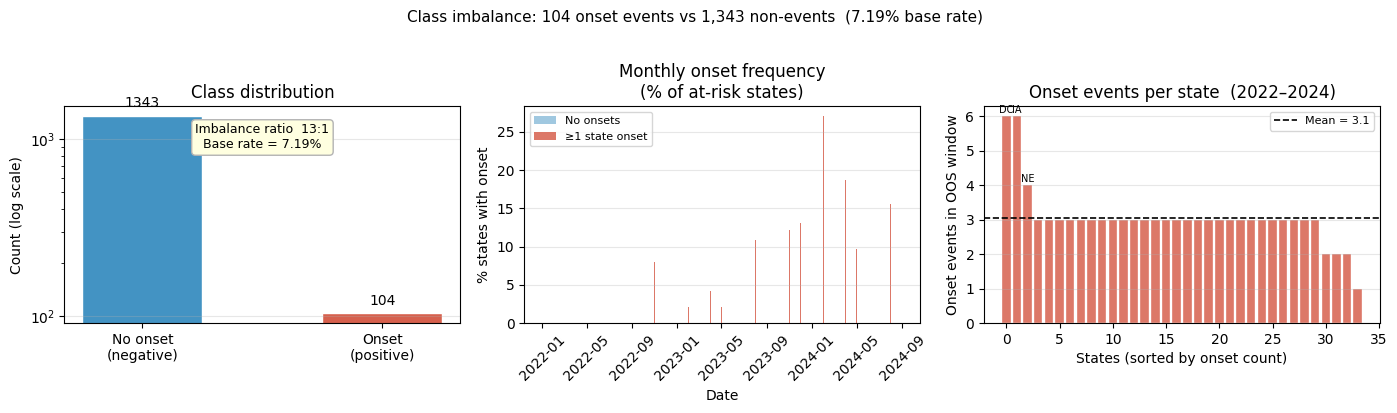

Saved → output/figures/06b_imbalance_overview.png


In [11]:
# ── 7a  Imbalance overview ────────────────────────────────────────────────────
n_neg = n_total - n_pos

monthly = (
    preds.groupby("date")[TARGET]
    .agg(n_onsets="sum", n_states="count")
    .assign(pct_states=lambda d: d["n_onsets"] / d["n_states"] * 100)
    .reset_index()
)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

ax = axes[0]
bars = ax.bar(["No onset\n(negative)", "Onset\n(positive)"],
              [n_neg, n_pos],
              color=["#4393c3", "#d6604d"], width=0.5, edgecolor="white")
ax.bar_label(bars, fmt="%d", padding=4, fontsize=10)
ax.set_yscale("log")
ax.set_ylabel("Count (log scale)")
ax.set_title("Class distribution")
ax.text(0.5, 0.92,
        f"Imbalance ratio  {n_neg/n_pos:.0f}:1\nBase rate = {n_pos/n_total:.2%}",
        transform=ax.transAxes, ha="center", va="top", fontsize=9,
        bbox=dict(boxstyle="round,pad=0.3", fc="lightyellow", ec="0.7"))
ax.grid(axis="y", alpha=0.3)

ax = axes[1]
onset_months = monthly[monthly["n_onsets"] > 0]
non_onset    = monthly[monthly["n_onsets"] == 0]
ax.bar(non_onset["date"],   non_onset["pct_states"],   color="#4393c3", alpha=0.5, label="No onsets")
ax.bar(onset_months["date"], onset_months["pct_states"], color="#d6604d", alpha=0.85, label="≥1 state onset")
ax.set_xlabel("Date")
ax.set_ylabel("% states with onset")
ax.set_title("Monthly onset frequency\n(% of at-risk states)")
ax.tick_params(axis="x", rotation=45)
ax.legend(fontsize=8)
ax.grid(axis="y", alpha=0.3)

ax = axes[2]
state_counts = (
    preds[preds[TARGET] == 1]
    .groupby("state_code")[TARGET].sum()
    .sort_values(ascending=False)
    .reset_index()
)
ax.bar(range(len(state_counts)), state_counts[TARGET],
       color="#d6604d", alpha=0.85, edgecolor="white", linewidth=0.3)
ax.set_xlabel("States (sorted by onset count)")
ax.set_ylabel("Onset events in OOS window")
ax.set_title("Onset events per state  (2022–2024)")
ax.axhline(state_counts[TARGET].mean(), color="k", lw=1.2, linestyle="--",
           label=f"Mean = {state_counts[TARGET].mean():.1f}")
ax.legend(fontsize=8)
ax.grid(axis="y", alpha=0.3)
for _, row in state_counts.head(3).iterrows():
    ax.text(_, row[TARGET] + 0.05, row["state_code"],
            ha="center", va="bottom", fontsize=7)

fig.suptitle(
    f"Class imbalance: {n_pos} onset events vs {n_neg:,} non-events  ({n_pos/n_total:.2%} base rate)",
    fontsize=11, y=1.02,
)
fig.tight_layout()
fig.savefig(FIG / "06b_imbalance_overview.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → output/figures/06b_imbalance_overview.png")

In [12]:
# ── 7b  Full imbalance-aware metrics table (Youden's J threshold) ──────────────
brier_ref = base_rate * (1 - base_rate)

metric_rows = []
for m in MODELS:
    col   = f"ons_preds_{m}"
    y     = preds[TARGET].values
    p     = preds[col].values

    fpr_, tpr_, thresh_ = roc_curve(y, p)
    j_idx = np.argmax(tpr_ - fpr_)
    tau_j = float(thresh_[j_idx])
    y_hat = (p >= tau_j).astype(int)

    tn, fp_c, fn_c, tp = confusion_matrix(y, y_hat).ravel()

    auc_roc = roc_auc_score(y, p)
    auc_pr  = average_precision_score(y, p)
    brier   = brier_score_loss(y, p)
    bss     = 1 - brier / brier_ref
    ll      = log_loss(y, p)
    f1      = f1_score(y, y_hat)
    mcc     = matthews_corrcoef(y, y_hat)
    bal_acc = balanced_accuracy_score(y, y_hat)
    sens    = tp / (tp + fn_c)
    spec    = tn / (tn + fp_c)

    metric_rows.append({
        "Model":       m,
        "τ_Youden":    round(tau_j, 4),
        "AUC-ROC":     round(auc_roc, 3),
        "AUC-PR":      round(auc_pr, 3),
        "F1":          round(f1, 3),
        "MCC":         round(mcc, 3),
        "Bal.Acc":     round(bal_acc, 3),
        "Sensitivity": round(sens, 3),
        "Specificity": round(spec, 3),
        "Brier":       round(brier, 4),
        "BSS":         round(bss, 3),
        "LogLoss":     round(ll, 3),
    })

metrics_df = pd.DataFrame(metric_rows)
metrics_df.to_csv(TBL / "06b_imbalance_metrics.csv", index=False)
print(metrics_df.to_string(index=False))
print("\nSaved → output/tables/06b_imbalance_metrics.csv")

Model  τ_Youden  AUC-ROC  AUC-PR    F1   MCC  Bal.Acc  Sensitivity  Specificity  Brier    BSS  LogLoss
   M0    0.4857    0.527   0.073 0.156 0.064    0.561        0.519        0.603 0.2486 -2.726    0.694
   M2    0.5210    0.835   0.293 0.346 0.338    0.784        0.779        0.789 0.1760 -1.638    0.525
   M3    0.4341    0.840   0.292 0.287 0.303    0.787        0.923        0.650 0.1697 -1.544    0.510
   M4    0.3821    0.831   0.301 0.288 0.297    0.777        0.885        0.670 0.1393 -1.088    0.435

Saved → output/tables/06b_imbalance_metrics.csv


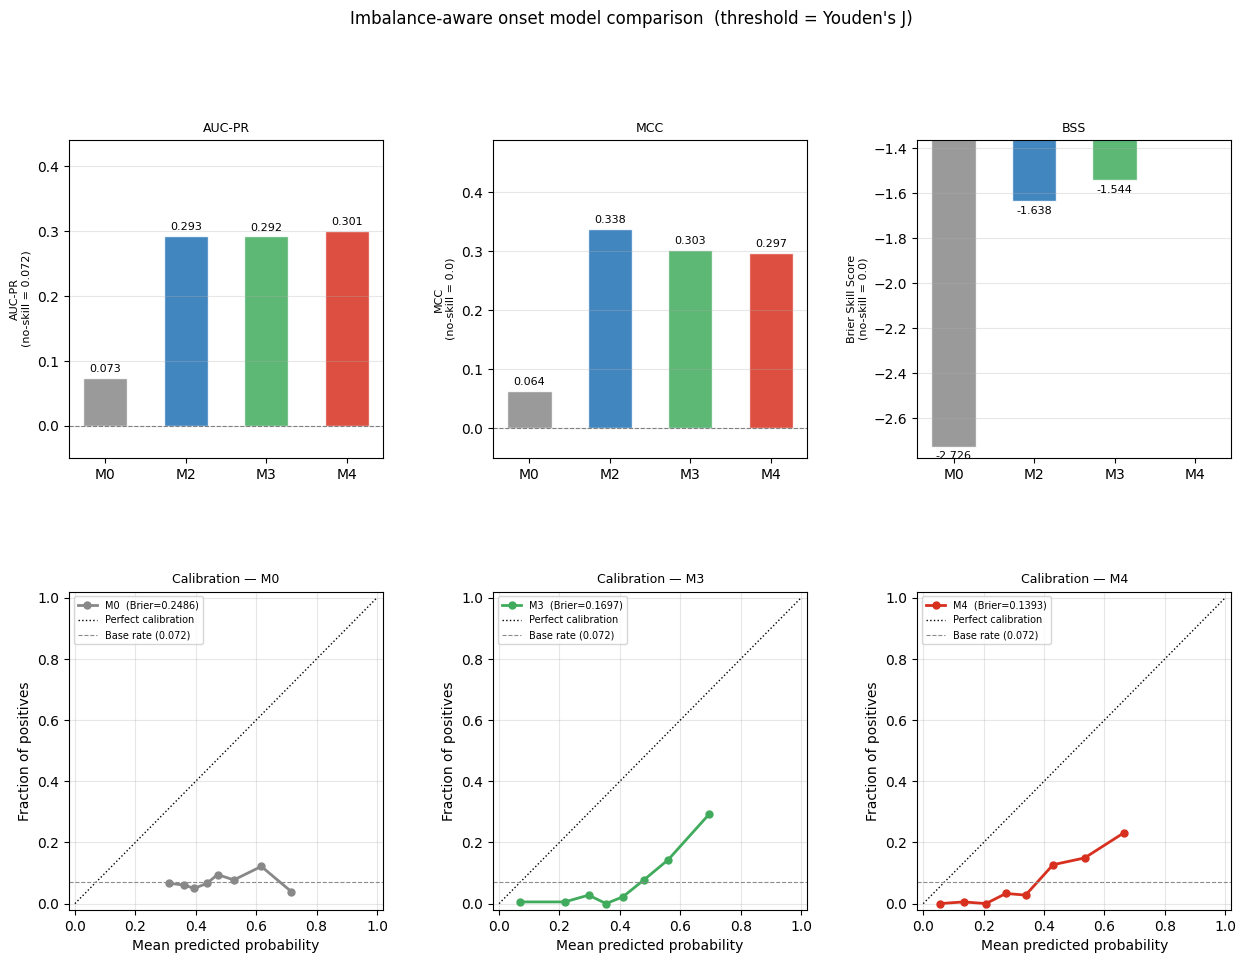

Saved → output/figures/06b_imbalance_metrics_chart.png


In [13]:
# ── 7c  Bar charts + calibration ──────────────────────────────────────────────
from sklearn.calibration import calibration_curve

fig = plt.figure(figsize=(15, 10))
gs  = fig.add_gridspec(2, 3, hspace=0.42, wspace=0.35)

bar_metrics = [
    ("AUC-PR", f"AUC-PR\n(no-skill = {base_rate:.3f})"),
    ("MCC",    "MCC\n(no-skill = 0.0)"),
    ("BSS",    "Brier Skill Score\n(no-skill = 0.0)"),
]

for col_idx, (metric, ylabel) in enumerate(bar_metrics):
    ax = fig.add_subplot(gs[0, col_idx])
    vals   = metrics_df[metric].values
    colors = [MODEL_COLS[m] for m in MODELS]
    bars   = ax.bar(MODELS, vals, color=colors, alpha=0.85, edgecolor="white", width=0.55)
    ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=8)
    ax.set_ylabel(ylabel, fontsize=8)
    ax.set_title(metric, fontsize=9)
    ax.axhline(0, color="0.5", lw=0.8, linestyle="--")
    ylo = min(min(vals) - 0.05, -0.05)
    ax.set_ylim(ylo, max(vals) * 1.3 + 0.05)
    ax.grid(axis="y", alpha=0.3)

for col_idx, m in enumerate(["M0", "M3", "M4"]):
    ax  = fig.add_subplot(gs[1, col_idx])
    col = f"ons_preds_{m}"
    y   = preds[TARGET].values
    p   = preds[col].values

    frac_pos, mean_pred = calibration_curve(y, p, n_bins=8, strategy="quantile")
    ax.plot(mean_pred, frac_pos, "o-", color=MODEL_COLS[m], lw=2, ms=5,
            label=f"{m}  (Brier={brier_score_loss(y,p):.4f})")
    ax.plot([0, 1], [0, 1], "k:", lw=1, label="Perfect calibration")
    ax.axhline(base_rate, color="0.55", lw=0.8, linestyle="--",
               label=f"Base rate ({base_rate:.3f})")
    ax.set_xlabel("Mean predicted probability")
    ax.set_ylabel("Fraction of positives")
    ax.set_title(f"Calibration — {m}", fontsize=9)
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)
    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(-0.02, 1.02)

fig.suptitle("Imbalance-aware onset model comparison  (threshold = Youden's J)",
             fontsize=12, y=1.01)
fig.savefig(FIG / "06b_imbalance_metrics_chart.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → output/figures/06b_imbalance_metrics_chart.png")